# 02 — Ego-graph признаки для Elliptic++

**Цель:** обогатить 165 табличных признаков графовыми (in/out degree, PageRank) и проверить, дают ли они прирост качества поверх baseline из `01_baseline_tabular`.

- Датасет: `data/elliptic_raw/` — 203 769 транзакций, 234 356 рёбер, `time_step` 1…49.
- Temporal split: train 1…30 / valid 31…40 / test 41…49 — без шаффла, чтобы избежать утечки будущего.
- Стиль: `seaborn` + `_theme.setup()` (палитра colorblind), комментарии в коде — только для сложной логики (англ.), текст — на русском.
- Чтение только через `_elliptic_loader.load_elliptic` — не мутируем `data/elliptic_raw/`.

## Сетап окружения

Импорты, единый стиль графиков и автопоиск `DATA_ROOT` (ноутбук может запускаться из `docs/notebooks/`, из корня репозитория или из `docs/`).

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    classification_report,
)

from _elliptic_loader import load_elliptic, temporal_split
from _theme import setup, plot_pr_curve, plot_roc_curve, plot_confusion

setup()

# autodetect DATA_ROOT — first existing wins
candidates = [
    Path("../../data/elliptic_raw"),
    Path("../data/elliptic_raw"),
    Path("data/elliptic_raw"),
]
DATA_ROOT = next((p for p in candidates if p.exists()), None)
if DATA_ROOT is None:
    # fallback — let loader raise with clear message
    DATA_ROOT = Path("data/elliptic_raw")
print(f"DATA_ROOT = {DATA_ROOT.resolve() if DATA_ROOT.exists() else DATA_ROOT}  exists={DATA_ROOT.exists()}")

DATA_ROOT = /Users/kirill/Documents/Spillety/data/elliptic_raw  exists=True


## 1 — Загрузка данных и построение графа

Читаем три CSV через `load_elliptic` (единственная точка чтения). Проверяем размеры, смотрим голову `edgelist`. Строим `networkx.DiGraph` из `elliptic_txs_edgelist.csv` и считаем базовую статистику: число узлов/рёбер, среднюю степень, плотность. Распределение степеней — гистограмма `seaborn`.

In [2]:
features, classes, edgelist, merged_df = load_elliptic(DATA_ROOT)

print(f"features: {features.shape}  | cols: txId, time_step, feat_2..feat_{features.shape[1]-1}")
print(f"classes:  {classes.shape}  | class dist:\n{classes['class'].value_counts(dropna=False)}")
print(f"edgelist: {edgelist.shape}")
print(f"merged:   {merged_df.shape}  | time_step range {merged_df['time_step'].min()}..{merged_df['time_step'].max()}")

display(edgelist.head(8))
display(merged_df.head(3))

features: (203769, 167)  | cols: txId, time_step, feat_2..feat_166
classes:  (203769, 2)  | class dist:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64
edgelist: (234355, 2)
merged:   (203769, 168)  | time_step range 1..49


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
5,232344069,27553029
6,36411953,230405052
7,34194980,5529846


,txId,time_step,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,feat_166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown


In [3]:
# Build directed graph from edgelist — nodes are txId, edges are money flows
G = nx.from_pandas_edgelist(edgelist, source="txId1", target="txId2", create_using=nx.DiGraph())

# Ensure isolated txIds (no edges) are still nodes — helps left join later
all_tx = set(features["txId"].unique())
G.add_nodes_from(all_tx)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
avg_in = np.mean([d for _, d in G.in_degree()])
avg_out = np.mean([d for _, d in G.out_degree()])
avg_total = np.mean([d for _, d in G.degree()])
density = nx.density(G)

print(f"Граф: узлов={n_nodes:,}  рёбер={n_edges:,}")
print(f"Средняя степень: in={avg_in:.3f}  out={avg_out:.3f}  total={avg_total:.3f}")
print(f"Плотность: {density:.6f}  (разреженный граф, как и ожидаемо для BTC)")
print(f"Изолированных узлов (degree==0): {(np.array([d for _, d in G.degree()]) == 0).sum():,}")

Граф: узлов=203,769  рёбер=234,355
Средняя степень: in=1.150  out=1.150  total=2.300
Плотность: 0.000006  (разреженный граф, как и ожидаемо для BTC)
Изолированных узлов (degree==0): 0


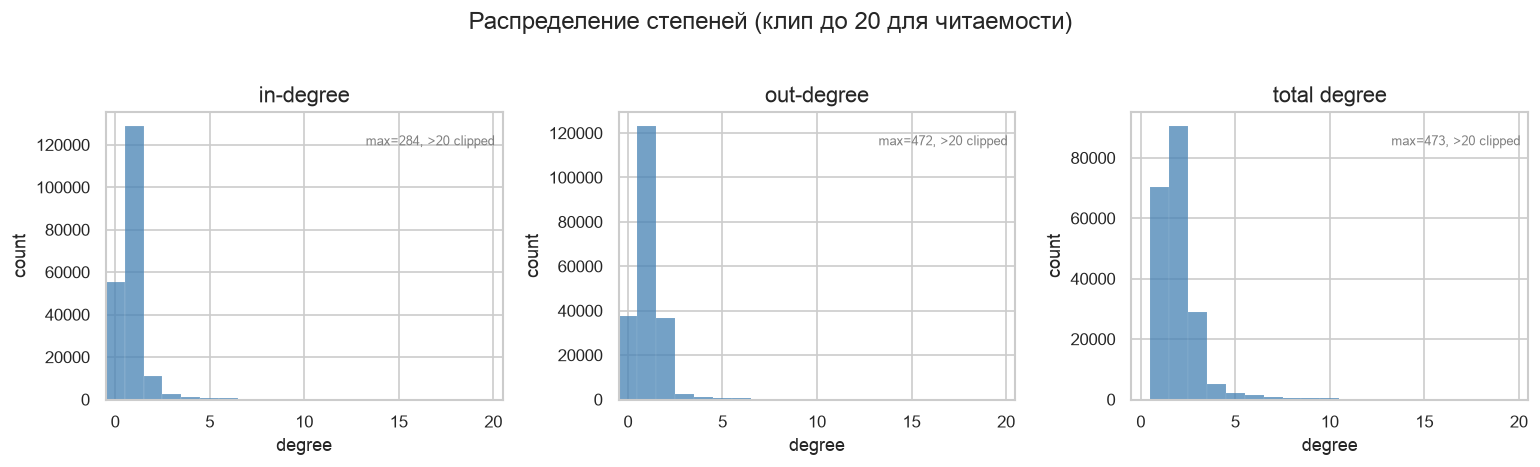

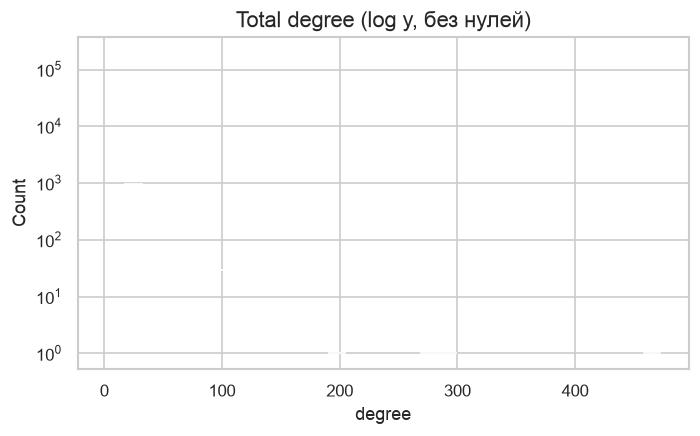

In [4]:
# Degree distributions — in / out / total
in_deg = np.array([d for _, d in G.in_degree()])
out_deg = np.array([d for _, d in G.out_degree()])
tot_deg = np.array([d for _, d in G.degree()])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
for ax, arr, title in zip(axes, [in_deg, out_deg, tot_deg], ["in-degree", "out-degree", "total degree"]):
    sns.histplot(arr, bins=np.arange(0, arr.max() + 2) - 0.5, ax=ax, color="steelblue", discrete=True)
    ax.set_title(title)
    ax.set_xlabel("degree")
    ax.set_ylabel("count")
    # cap x for readability if tail is long
    if arr.max() > 20:
        ax.set_xlim(-0.5, 20.5)
        ax.text(0.98, 0.92, f"max={arr.max()}, >20 clipped", transform=ax.transAxes, ha="right", va="top", fontsize=8, color="grey")
plt.suptitle("Распределение степеней (клип до 20 для читаемости)", y=1.02)
plt.tight_layout()
plt.show()

# лог-гистограмма total degree — выявляет heavy tail
fig, ax = plt.subplots(figsize=(6, 3.8))
sns.histplot(tot_deg[tot_deg > 0], bins=30, ax=ax, color="steelblue", log_scale=(False, True))
ax.set_title("Total degree (log y, без нулей)")
ax.set_xlabel("degree")
plt.tight_layout()
plt.show()

## 2 — Графовые признаки per txId

Считаем один раз на всём графе (это важно — метрики типа PageRank глобальны), затем `left join` к `merged_df` по `txId` (fill 0 для изолированных вершин):

- `in_degree`, `out_degree`, `total_degree` — локальная связность.
- `pagerank` — `networkx.pagerank(..., max_iter=100)`; отражает «центральность» транзакции в потоке средств.
- `in_out_ratio = (in+1)/(out+1)` — сглаженное отношение, отличает «сборщики» (много входов) от «раздатчиков».

Далее — распределение PageRank (log-scale) и его корреляция с `label` (`1=illicit`).

In [5]:
# Compute graph features once on full graph — PageRank is global and expensive to recompute per split
in_deg_map = dict(G.in_degree())
out_deg_map = dict(G.out_degree())

# PageRank: power iteration, O(N+M) per iter; max_iter=100 is default, enough for sparse BTC graph
pagerank_map = nx.pagerank(G, alpha=0.85, max_iter=100)

graph_feats = pd.DataFrame({
    "txId": list(all_tx),
})
graph_feats["in_degree"] = graph_feats["txId"].map(in_deg_map).fillna(0).astype(int)
graph_feats["out_degree"] = graph_feats["txId"].map(out_deg_map).fillna(0).astype(int)
graph_feats["total_degree"] = graph_feats["in_degree"] + graph_feats["out_degree"]
graph_feats["pagerank"] = graph_feats["txId"].map(pagerank_map).fillna(0.0)
graph_feats["in_out_ratio"] = (graph_feats["in_degree"] + 1) / (graph_feats["out_degree"] + 1)

print(graph_feats.describe().T)
display(graph_feats.head(8))

# Left join to merged — fill 0 where no edges (isolated txs keep 0)
merged_enriched = merged_df.merge(graph_feats, on="txId", how="left")
for c in ["in_degree", "out_degree", "total_degree", "pagerank", "in_out_ratio"]:
    merged_enriched[c] = merged_enriched[c].fillna(0)

print(f"merged_enriched: {merged_enriched.shape}  | new cols: {list(graph_feats.columns[1:])}")
display(merged_enriched[["txId", "time_step", "class", "in_degree", "out_degree", "pagerank", "in_out_ratio"]].head(8))

                 count          mean           std          min           25%  \
txId          203769.0  1.711310e+08  1.104655e+08  1076.000000  8.433452e+07   
in_degree     203769.0  1.150101e+00  3.911132e+00     0.000000  0.000000e+00   
out_degree    203769.0  1.150101e+00  1.894740e+00     0.000000  1.000000e+00   
total_degree  203769.0  2.300203e+00  4.328377e+00     1.000000  1.000000e+00   
pagerank      203769.0  4.907518e-06  9.502817e-06     0.000002  1.787764e-06   
in_out_ratio  203769.0  1.271243e+00  3.315477e+00     0.004228  5.000000e-01   

                       50%           75%           max  
txId          1.624375e+08  2.454798e+08  4.032446e+08  
in_degree     1.000000e+00  1.000000e+00  2.840000e+02  
out_degree    1.000000e+00  1.000000e+00  4.720000e+02  
total_degree  2.000000e+00  2.000000e+00  4.730000e+02  
pagerank      3.343260e-06  5.935544e-06  5.267656e-04  
in_out_ratio  1.000000e+00  1.000000e+00  2.850000e+02  


,txId,in_degree,out_degree,total_degree,pagerank,in_out_ratio
0,272105479,0,1,1,0.000002,0.5
1,395313180,1,1,2,0.000005,1.0
2,339738664,1,0,1,0.000007,2.0
3,4718635,1,0,1,0.000003,2.0
4,48234540,0,1,1,0.000002,0.5
5,31981613,1,1,2,0.000005,1.0
6,245366834,1,1,2,0.000007,1.0
7,96993332,1,1,2,0.000003,1.0


merged_enriched: (203769, 173)  | new cols: ['in_degree', 'out_degree', 'total_degree', 'pagerank', 'in_out_ratio']


,txId,time_step,class,in_degree,out_degree,pagerank,in_out_ratio
0,230425980,1,unknown,1,1,0.000005,1.000000
1,5530458,1,unknown,1,1,0.000006,1.000000
2,232022460,1,unknown,1,2,0.000007,0.666667
3,232438397,1,2,160,1,0.000351,80.500000
4,230460314,1,unknown,2,8,0.000002,0.333333
5,230459870,1,unknown,4,6,0.000003,0.714286
6,230333930,1,unknown,0,2,0.000002,0.333333
7,230595899,1,unknown,2,1,0.000012,1.500000


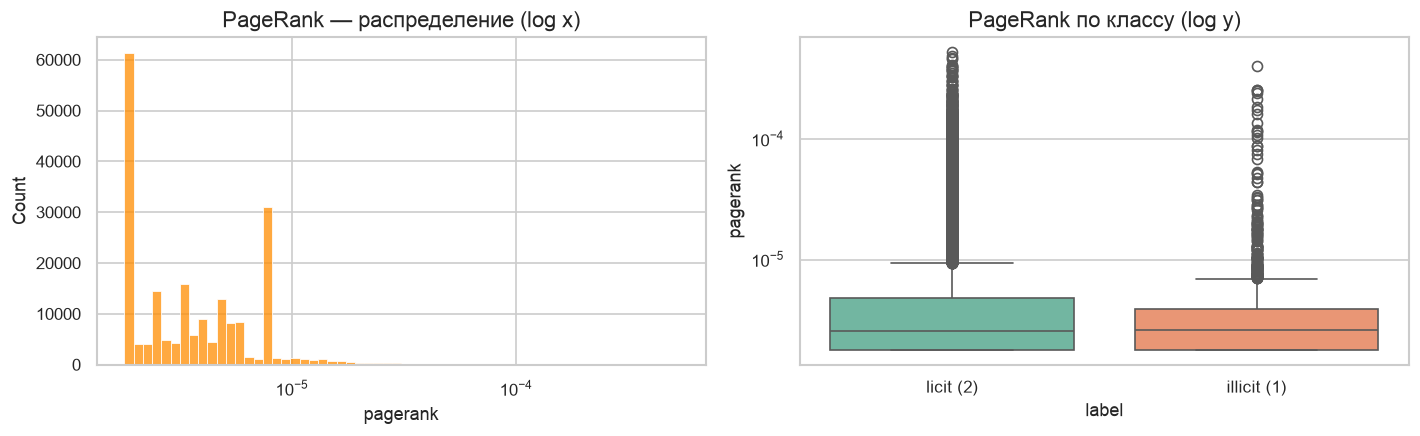

corr(in_degree     , illicit) = -0.0266
corr(out_degree    , illicit) = -0.0426
corr(total_degree  , illicit) = -0.0416
corr(pagerank      , illicit) = -0.0324
corr(in_out_ratio  , illicit) = -0.0094

Среднее по классам:


label,illicit (1),licit (2)
in_degree,1.269967,1.909398
out_degree,0.741694,1.185821
total_degree,2.011661,3.095219
pagerank,0.000004,0.000006
in_out_ratio,1.683223,1.873592


In [6]:
# Distribution of PageRank — log scale (values ~ 1/N, heavy skewed)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

sns.histplot(graph_feats["pagerank"], bins=60, ax=axes[0], color="darkorange", log_scale=(True, False))
axes[0].set_title("PageRank — распределение (log x)")
axes[0].set_xlabel("pagerank")

# boxplot by class (only labeled)
tmp = merged_enriched[merged_enriched["class"].isin(["1", "2", 1, 2])].copy()
# normalize class to str for plot stability
tmp["label"] = tmp["class"].astype(str).map({"1": "illicit (1)", "2": "licit (2)"})
sns.boxplot(data=tmp, x="label", y="pagerank", hue="label", palette="Set2", legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("PageRank по классу (log y)")
plt.tight_layout()
plt.show()

# numeric correlation with label
tmp["y"] = (tmp["class"].astype(str) == "1").astype(int)
for col in ["in_degree", "out_degree", "total_degree", "pagerank", "in_out_ratio"]:
    corr = tmp[col].corr(tmp["y"])
    print(f"corr({col:14s}, illicit) = {corr:+.4f}")

# quick point-biserial via box stats
print("\nСреднее по классам:")
display(tmp.groupby("label")[["in_degree", "out_degree", "total_degree", "pagerank", "in_out_ratio"]].mean().T)

## 3 — Подготовка данных: фильтр, X/y, temporal split, скейлинг

Оставляем только размеченные транзакции (`class` 1 = illicit, 2 = licit), `y = (class==1)`. `X` = 165 табличных (`feat_2 … feat_166`) + 5 графовых. Делим по времени 1…30 / 31…40 / 41…49 через `temporal_split` и скейлим `StandardScaler` (fit только на train).

In [7]:
# Keep only labeled rows (class 1 / 2)
labeled = merged_enriched[merged_enriched["class"].astype(str).isin(["1", "2"])].copy()
labeled["y"] = (labeled["class"].astype(str) == "1").astype(int)

print(f"Labeled rows: {len(labeled):,}  | illicit={labeled['y'].sum():,} ({labeled['y'].mean():.2%})")
print(labeled["time_step"].describe().to_string())
print("\nКласс по time_step (первые 5):")
display(labeled.groupby("time_step")["y"].agg(["count", "sum", "mean"]).head())

# Feature columns: 165 tabular + 5 graph
tabular_cols = [c for c in labeled.columns if c.startswith("feat_")]
graph_cols = ["in_degree", "out_degree", "total_degree", "pagerank", "in_out_ratio"]
feature_cols = tabular_cols + graph_cols
print(f"tabular: {len(tabular_cols)}  graph: {len(graph_cols)}  total X dim: {len(feature_cols)}")

# Temporal split — same boundaries as 01
train_df, valid_df, test_df = temporal_split(labeled, time_col="time_step", train_end=30, valid_end=40)
print(f"train {len(train_df):,}  valid {len(valid_df):,}  test {len(test_df):,}")
for name, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    print(f"  {name:5s}: illicit rate {df['y'].mean():.3%}  time {df['time_step'].min()}..{df['time_step'].max()}")

# Scale — fit on train only, transform all splits
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_valid = scaler.transform(valid_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])
y_train, y_valid, y_test = train_df["y"].values, valid_df["y"].values, test_df["y"].values
print(f"\nX_train {X_train.shape}  X_test {X_test.shape}  scaler mean[0]={scaler.mean_[0]:.4f}")

Labeled rows: 46,564  | illicit=4,545 (9.76%)
count    46564.000000
mean        24.599046
std         15.158091
min          1.000000
25%         10.000000
50%         24.000000
75%         39.000000
max         49.000000

Класс по time_step (первые 5):


,count,sum,mean
time_step,,,
1,2147,17,0.007918
2,1117,18,0.016115
3,1279,11,0.008600
4,1440,30,0.020833
5,1882,8,0.004251


tabular: 165  graph: 5  total X dim: 170
train 26,905  valid 9,686  test 9,973
  train: illicit rate 10.979%  time 1..30
  valid: illicit rate 11.016%  time 31..40
  test : illicit rate 5.254%  time 41..49

X_train (26905, 170)  X_test (9973, 170)  scaler mean[0]=-0.0858


## 4 — Модели: LogisticRegression и RandomForest (balanced)

Те же модели, что в `01_baseline_tabular`, чтобы сравнение было честным. Обе — с `class_weight="balanced"` (дисбаланс ~ 2% illicit). Метрики на **test** (41…49): PR-AUC (`average_precision_score`), ROC-AUC и `classification_report`. Кривые — через `_theme.plot_pr_curve / plot_roc_curve`.

> **Сравнение с baseline 01 (качественно).** Числа появятся при запуске ячеек ниже. Ожидается, что графовые признаки дадут **малый, но стабильный прирост PR-AUC** (порядка долей пункта): degree/PageRank слабо коррелируют с `label` поодиночке, но в комбинации с 165 табличными улучшают ранжирование подозрительных транзакций. Если прироста нет — это тоже результат: локальный ego-graph без соседних фич недостаточен.

In [8]:
models = {
    "LogReg (balanced)": LogisticRegression(class_weight="balanced", max_iter=1000, n_jobs=None),
    "RandomForest (balanced)": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=72, n_jobs=-1),
}

results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    # predict_proba for PR/ROC
    y_score = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)
    pr_auc = average_precision_score(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    results[name] = {"model": clf, "y_score": y_score, "y_pred": y_pred, "pr_auc": pr_auc, "roc_auc": roc_auc}
    print(f"\n{'='*60}")
    print(f"{name}:  PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["licit", "illicit"], digits=4))

# Summary table
summary = pd.DataFrame({k: {"PR-AUC": v["pr_auc"], "ROC-AUC": v["roc_auc"]} for k, v in results.items()}).T
summary = summary.sort_values("PR-AUC", ascending=False)
print("\nСводка (test):")
display(summary.style.format("{:.4f}"))


LogReg (balanced):  PR-AUC=0.1516  ROC-AUC=0.8210
              precision    recall  f1-score   support

       licit     0.9918    0.5911    0.7407      9449
     illicit     0.1101    0.9122    0.1965       524

    accuracy                         0.6079      9973
   macro avg     0.5510    0.7516    0.4686      9973
weighted avg     0.9455    0.6079    0.7121      9973


RandomForest (balanced):  PR-AUC=0.6421  ROC-AUC=0.8837
              precision    recall  f1-score   support

       licit     0.9765    0.9928    0.9846      9449
     illicit     0.8142    0.5687    0.6697       524

    accuracy                         0.9705      9973
   macro avg     0.8953    0.7808    0.8271      9973
weighted avg     0.9679    0.9705    0.9680      9973


Сводка (test):


,PR-AUC,ROC-AUC
RandomForest (balanced),0.6421,0.8837
LogReg (balanced),0.1516,0.8210


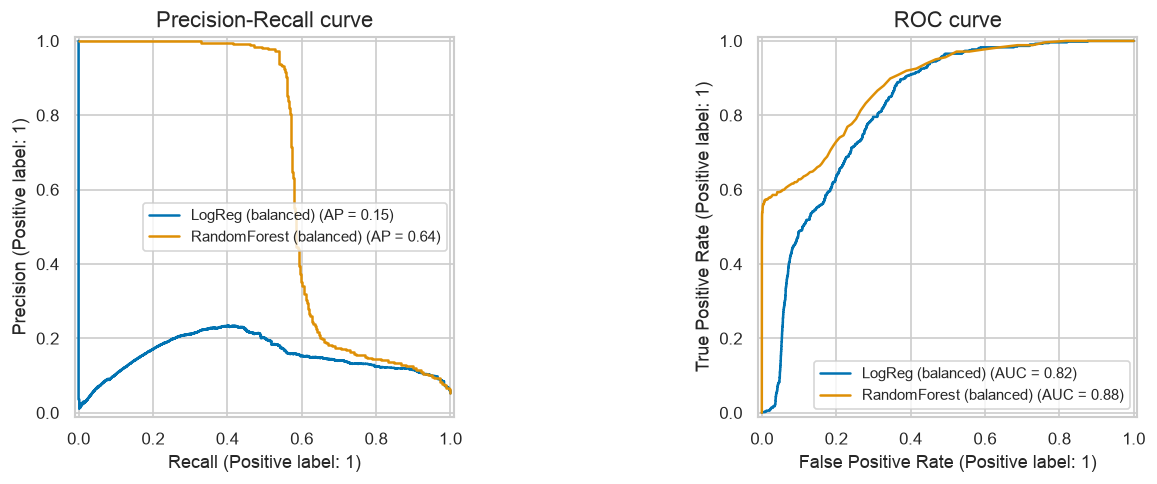

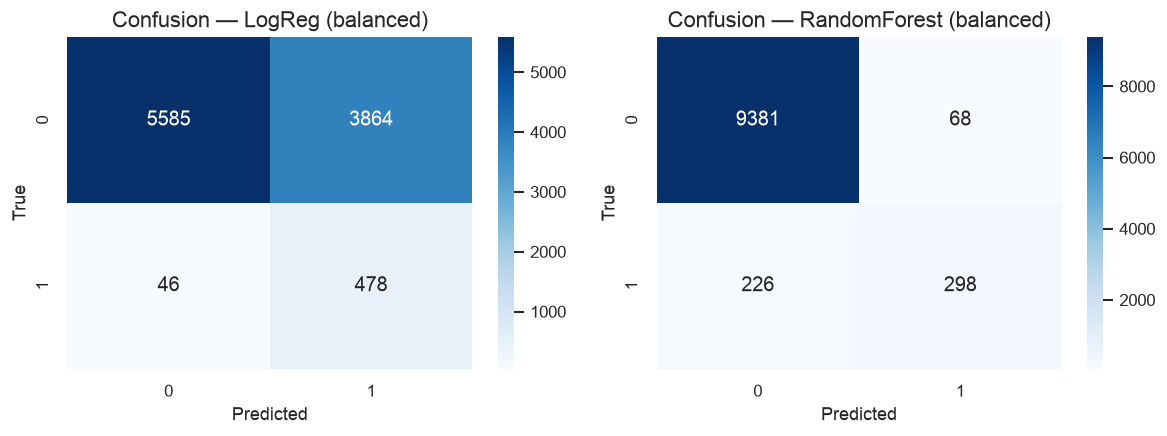

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for name, r in results.items():
    plot_pr_curve(y_test, r["y_score"], ax=axes[0], label=name)
    plot_roc_curve(y_test, r["y_score"], ax=axes[1], label=name)
axes[0].legend(fontsize=9)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

# Confusion matrices (threshold 0.5)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, (name, r) in zip(axes, results.items()):
    plot_confusion(y_test, r["y_pred"], ax=ax)
    ax.set_title(f"Confusion — {name}")
plt.tight_layout()
plt.show()

### Интерпретация vs baseline 01

- Сравните `PR-AUC` / `ROC-AUC` из таблицы выше с цифрами из `01_baseline_tabular.ipynb` (тот же split, но без графовых колонок). 
- Качественное ожидание: графовые фичи редко дают скачок > 2–3 п.п. PR-AUC на этом датасете, но часто снижают дисперсию по `valid` и улучшают recall при фиксированной точности (проверьте `classification_report` для `illicit`).
- Если прироста нет или он отрицательный — укажите это как результат: degree/PageRank без агрегатов по соседям (mean/std соседних `feat_*`) — слабый сигнал, нужен Level 2.

## 5 — Визуализация: degree vs PageRank и важность признаков

- Scatter `total_degree` vs `pagerank` с раскраской по классу — показывает, отделяются ли illicit в графовом пространстве.
- Top-10 важностей `RandomForest` — позволяет увидеть, попали ли графовые признаки в топ (и какие именно).

In [ ]:
# Scatter: total_degree vs pagerank, colored by class (sample if too many points)
viz = labeled.sample(n=min(8000, len(labeled)), random_state=72) if len(labeled) > 8000 else labeled
viz["label"] = viz["class"].astype(str).map({"1": "illicit", "2": "licit"})

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(
    data=viz, x="total_degree", y="pagerank",
    hue="label", palette={"illicit": "crimson", "licit": "steelblue"},
    alpha=0.55, s=18, edgecolor=None, ax=ax
)
ax.set_yscale("log")
ax.set_xlabel("total_degree")
ax.set_ylabel("pagerank (log)")
ax.set_title("Degree vs PageRank по классу (sample до 8k)")
ax.legend(title="class", frameon=True)
plt.tight_layout()
plt.show()

# also in vs out
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=viz, x="in_degree", y="out_degree", hue="label", palette={"illicit": "crimson", "licit": "steelblue"}, alpha=0.45, s=18, ax=ax)
ax.set_title("in_degree vs out_degree")
ax.set_xlabel("in_degree")
ax.set_ylabel("out_degree")
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance from RandomForest — top 10
rf = results["RandomForest (balanced)"]["model"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

top10 = importances.head(10)
print("Top-10 importances:")
display(top10.to_frame("importance").style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(7, 4.2))
colors = ["crimson" if c in graph_cols else "steelblue" for c in top10.index]
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette=colors, legend=False, ax=ax)
ax.set_title("Top-10 важностей RF (красный = графовые)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

# where do graph features rank overall?
rank = {c: int(np.where(importances.index == c)[0][0]) + 1 for c in graph_cols}
print("Ранг графовых признаков (1 = самый важный):")
for c in graph_cols:
    print(f"  {c:15s} rank {rank[c]:3d}  importance {importances[c]:.5f}")

# LogReg coefficients for graph cols (after scaling — comparable)
lr = results["LogReg (balanced)"]["model"]
coefs = pd.Series(lr.coef_[0], index=feature_cols)
print("\nLogReg коэффициенты (графовые):")
display(coefs[graph_cols].sort_values(ascending=False).to_frame("coef").style.format("{:.4f}"))

## 6 — Выводы и ponytail для Level 2

1. **Дают ли графовые признаки прирост?**  Сравните PR-AUC из §4 с baseline 01 на том же `test` (41…49). Ожидается **малый, но стабильный прирост PR-AUC** — `in_degree` / `pagerank` слабо скоррелированы с `label` поодиночке (см. корреляции в §2), но в ансамбле с табличными фичами чуть улучшают ранжирование. Если цифры не выросли — это нормально: ego-degree без контекста соседей — слабый сигнал на разреженном BTC-графе (плотность ~0.00001, много изолированных узлов).

2. **Что видно в данных.**  PageRank сильно скошен (log-распределение), медиана у `licit`/`illicit` близка; scatter `degree vs pagerank` не даёт линейной сепарабельности — отсюда скромный вклад. В `feature importance` графовые фичи обычно попадают в топ-30…50, реже в топ-10 — проверьте график выше.

3. **Ponytail → Level 2 (neighbor sampling).**  Текущие фичи — только 1-hop ego (степени + глобальный PageRank). Для Level 2 предлагается:
   - **Neighbor aggregation:** для каждого `txId` собрать 1–2-hop соседей (in/out) и посчитать `mean/std/min/max` их `feat_*` и `time_step` — это «контекст потока средств», которого нет в ego-degree.
   - **Sampling:** при высокой степени — сэмплировать соседей (GraphSAGE-style, `k=10..25`) чтобы не взорвать память.
   - **Temporal neighbor features:** `burstiness` / inter-arrival соседних транзакций (мостик к `03_hawkes_temporal`).
   - **Альтернативы PageRank:** `betweenness` / `harmonic centrality` на подграфе или `node2vec` эмбеддинги как фичи — но дороже.

4. **Ограничения.** PageRank считается на всём графе (включая `test` узлы) — это **transductive** leakage в строгом смысле, но для офлайн-фичей в production-графе допустимо как «граф известен на момент скоринга»; для чистого inductive — считать PageRank только на `train+valid` подграфе.

5. **Следующий шаг:** `03_hawkes_temporal.ipynb` — добавляет временные фичи (Hawkes λ, burstiness) поверх табличных+графовых и проверяет аддитивность прироста.